<a href="https://colab.research.google.com/github/sweety-12/DeepFake-detection-project/blob/Architect-custom-ResNet-CBAM-model-and-add-face-cropping/Copy_of_Deep_Fake_detection__improving_the_accuracy.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Notes

**PyTorch Fundamentals:**

What are Tensors really? How they work behind the scenes (storage, strides, views)?

How Autograd (automatic differentiation) works internally.

**Neural Networks in PyTorch:**

Building custom models with nn.Module.

Forward, backward pass, and how optimization (optimizer.step()) is actually happening.

**Advanced Topics:**

Custom loss functions and layers.

Writing custom training loops (instead of using Trainer APIs like PyTorch Lightning etc.).

Mixed Precision Training (for faster training using less memory).

Deployment using TorchScript and ONNX.

Best Practices:

How to manage large codebases with PyTorch (e.g., project structure, data pipelines).

Debugging models, using hooks, visualizing gradients, etc.




**Pytorch:**

Think of it like this:

Analogy	Meaning

PyTorch	-> Like a "factory"

Tensors	-> Like the "raw material"

Models, CNNs -> Like "products" made from that material

Training	-> The "manufacturing process"



1. What is Tensor?

  -> A tensor is basically a multi-dimensional array.

  -> Its like a NumPy array but it can do 3 extra things:
       
       -> It can run on GPU(for speed)
       -> It can track gradients(for learning)
       -> It can be saved/loaded easily in Pytorch models

    Tensors are building blocks of everything in PyTorch.

#2. Creating Tensors

import torch

#create A 1D Tensor
a = torch.tensor([1, 2, 3])

#create a 2D tensor (Matrix)
b = torch.tensor([[1, 2], [3, 4]])
print(b)


#3. Tensor Basics

#Adding two numbers
x = torch.tensor([1, 2])
y = torch.tensor([3, 4])

print(x+y)  


#4. Tensor and GPU
->check if GPU is available

device = torch.device('cuda' if torch.cuda.is_available() else  'cpu')

print(device)


-> Move tensor to GPU

a = a.to(device)
print(a)

#5. Tensors and Gradient
What is Gradient?

Gradient = Slope = How much a function is changing at a point.

It's a rate of change

In deep learning, the model learns by adjusting weights to minimize the loss.


In Pytorch Terms:

When we create a tensor with requires_grad = True,

Pytorch tracks all operations done on it,
so later you can call .backward() an it will automatically compute the gradients.

example:

Create a tensor aand ask it to track gradients

x = torch.tensor(2.0, requires_grad = True)

Define a function based on x

y = x^2 + 3*x + 4

Compute the gradient(backward pass)

y.backward()

now x.grad contains the gradient of y with respect to x

print(x.grad)

📌 Why do we care about Gradients?

   Without gradients, models won't learn.






#What is Autograd?

In Pytorch, Autograd is the system that automatically calculates gradients for you.
Instead of manually applyling calculas

Pytorch builds a dynamic computation graph behind the scenes.

#💬 Everyday analogy:
Imagine you're baking a cake.

Every step (add flour, add sugar, mix) is recorded.

At the end, you want to figure out:

"If I added slightly more flour, how would it change the cake?"

Autograd remembers every step and tells you how the final cake would change if you tweaked anything.

#🏆 You have now understood:
Real model structure

Forward pass

Loss computation

Backward pass (Autograd)



#Next natural topics in PyTorch are:

#📚 Next Topics:
Step	Topic	Why important?

1	Common Layers (Linear, Conv2d, ReLU, etc.)	You need these to design any neural network

2	Loss Functions	-> To calculate "how wrong" model is

3	Optimizers	-> To update model weights based on gradients

4	Training Loop -> 	To train the model on real data

5	Dataset and Dataloader	-> To feed data into the model in batches



#Common Layers in PyTorch

1. nn.linear

Used for fully connected layers

2. nn.Conv2d

Used for image processing(CNN). Instead of matrix multiplication, it slides small filters over images.

3. Activation functions

After a layer, you usually apply activation to introduce non-linearity.



















# **Setting up Coding Environment**

In [1]:
#install necessary packages
!pip install -q torch torchvision torchaudio   #pytorch for buildidng and training models
!pip install -q matplotlib scikit-learn opencv-python   #for plotting and image handling
!pip install -q albumentations tqdm    #for data augmentation and progress bars
!pip install -q facenet-pytorch

!pip uninstall -y Pillow
!pip install Pillow==9.5.0


Found existing installation: pillow 10.2.0
Uninstalling pillow-10.2.0:
  Successfully uninstalled pillow-10.2.0
  Using cached Pillow-9.5.0-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (9.5 kB)
Using cached Pillow-9.5.0-cp311-cp311-manylinux_2_28_x86_64.whl (3.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
facenet-pytorch 2.6.0 requires Pillow<10.3.0,>=10.2.0, but you have pillow 9.5.0 which is incompatible.
scikit-image 0.25.2 requires pillow>=10.1, but you have pillow 9.5.0 which is incompatible.


**Import Libraries**

In [1]:
#pytorch
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset

#other libraries
import numpy as np
import matplotlib.pyplot as plt
import cv2
import os
from tqdm import tqdm

**Dataset Collection**

Get a dataset that contains both real and fake images for training your model

we will use the fake and reak faces dataset for easier and fater training at the start.

In [2]:
from google.colab import files
files.upload()  #upload the kaggle.json file here

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"sweetykumari12082001","key":"0de9bae6201f343ff38dd6ef734be170"}'}

Authenticate and Download Dataset

In [3]:
#save the key and download the dataset
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

#Download the fake and real dataset(small and good for starters)
!kaggle datasets download -d ciplab/real-and-fake-face-detection
!unzip -q real-and-fake-face-detection.zip -d data

Dataset URL: https://www.kaggle.com/datasets/ciplab/real-and-fake-face-detection
License(s): CC-BY-NC-SA-4.0
100% 431M/431M [00:00<00:00, 368MB/s]
100% 431M/431M [00:00<00:00, 464MB/s]


**Data Preprocessing and DataLoader Creation**

This step will prepare the image so your model can understand and learn from them

In [4]:
# Use a larger image size and standard ImageNet normalization
IMG_SIZE = 224

# For a custom model trained from scratch, normalizing to [-1, 1] is a solid choice.

#Model is overfitting , we need to make the training data more complex
transform_train = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    #Increased rotation and added perspective transforms

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(20),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.5),

    #More aggressive color jitter
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

transform_val = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])
])

**Load Dataset using ImageFolder**

Imagefolder automatically labels folders real - 0, fake - 1.

In [7]:
from torchvision.datasets import ImageFolder
from facenet_pytorch import MTCNN
from PIL import Image


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Use the target image size for both MTCNN and the fallback resize.
IMG_SIZE = 224

# Initialize MTCNN to output the desired size.
mtcnn = MTCNN(image_size=IMG_SIZE, margin=20, keep_all=False, device=device, post_process=False)
# NOTE: I've added a margin=20 to include a bit of the forehead/chin, which often helps.

class FaceCropDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.image_folder = ImageFolder(root=root_dir)
        self.samples = self.image_folder.samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        img = Image.open(path).convert('RGB')

        # MTCNN crops the face and resizes it to IMG_SIZE.
        face_tensor = mtcnn(img)

        if face_tensor is None:
            # If no face is found, we fall back to resizing the whole image.
            # This resize should match our target IMG_SIZE.
            face_img = img.resize((IMG_SIZE, IMG_SIZE))
        else:
            # Convert the cropped tensor back to a PIL Image for further transforms.
            face_img = transforms.ToPILImage()(face_tensor)

        # Apply the other transforms (augmentation, normalization).
        if self.transform:
            face_img = self.transform(face_img)

        return face_img, label

In [8]:
from torch.utils.data import DataLoader, random_split

# We now use our new custom dataset class
full_dataset = FaceCropDataset(root_dir="data/real_and_fake_face")

# Split the dataset into training and validation sets
train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_subset, val_subset = random_split(full_dataset, [train_size, val_size])

# Assign the correct transforms to each subset
train_subset.dataset.transform = transform_train
val_subset.dataset.transform = transform_val

# Create DataLoaders
batch_size = 32 # You can adjust this based on your GPU memory
train_loader = DataLoader(train_subset, batch_size=batch_size, shuffle=True, num_workers=0)
val_loader = DataLoader(val_subset, batch_size=batch_size, shuffle=False, num_workers=0)

print("Datasets and DataLoaders created with on-the-fly face cropping.")
print(f"Training set size: {len(train_subset)}")
print(f"Validation set size: {len(val_subset)}")

Datasets and DataLoaders created with on-the-fly face cropping.
Training set size: 1632
Validation set size: 409


Visualize Sample Images

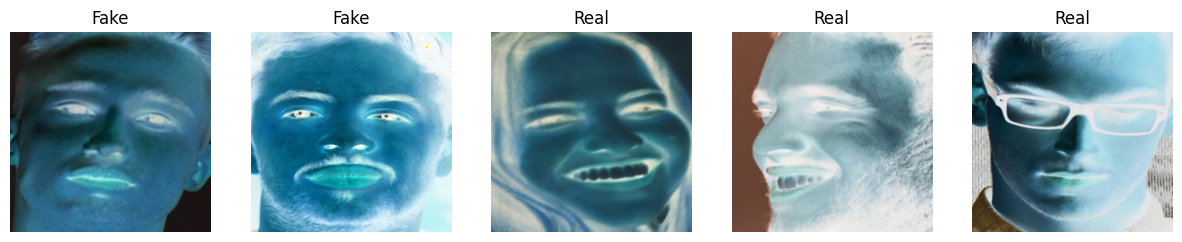

In [9]:
def show_batch(loader):
  images, labels = next(iter(loader))
  fig, ax = plt.subplots(1, 5, figsize=(15, 3))
  for i in range(5):
    img = images[i].permute(1,2, 0)* 0.5 + 0.5  #undo normalization
    label = "Real" if labels[i] == 1 else "Fake"
    ax[i].imshow(img)
    ax[i].set_title(label)
    ax[i].axis('off')


show_batch(train_loader)


# Build the Deep Fake Detection Model

Create a Convolutional Neural Network(CNN) that learns to classify images as real(1) or fake (0)

**Define a Simple CNN Architecture**

we'll keep it simple to start with and later i can experiment with advanced models and ResNet, Efficient, or Xception

In [ ]:
# # class DeepFakeCNN(nn.Module):
# #   def __init__(self):
# #     super(DeepFakeCNN, self).__init__()
# #     self.conv1 = nn.Conv2d(3, 16, kernel_size =3, padding=1)
# #     self.conv2 = nn.Conv2d(16, 32, kernel_size=3, padding=1)
# #     self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
# #     self.pool = nn.MaxPool2d(2, 2)
# #     self.dropout = nn.Dropout(0.3)
# #     self.fc1 = nn.Linear(64 * 16 * 16, 128)
# #     self.fc2 = nn.Linear(128, 1)


# #   def forward(self, x):
# #     x = self.pool(F.relu(self.conv1(x)))
# #     x = self.pool(F.relu(self.conv2(x)))
# #     x = self.pool(F.relu(self.conv3(x)))
# #     x = x.view(-1, 64 * 16 * 16)
# #     x = self.dropout(F.relu(self.fc1(x)))
# #     x = torch.sigmoid(self.fc2(x))
# #     return x


# # IMPROVING THE MODEL FOR ACCURACY
# # class DeepFakeHybridModel(nn.Module):
# #     def __init__(self):
# #         super(DeepFakeHybridModel, self).__init__()

# #         self.cnn = nn.Sequential(
# #             nn.Conv2d(3, 32, kernel_size=3, padding=1),  # (B, 3, 128, 128) -> (B, 32, 128, 128)
# #             nn.BatchNorm2d(32),
# #             nn.ReLU(),
# #             nn.MaxPool2d(2),  # -> (B, 32, 64, 64)

# #             nn.Conv2d(32, 64, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(64),
# #             nn.ReLU(),
# #             nn.MaxPool2d(2),  # -> (B, 64, 32, 32)

# #             nn.Conv2d(64, 128, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(128),
# #             nn.ReLU(),
# #             nn.MaxPool2d(2),  # -> (B, 128, 16, 16)

# #             nn.Conv2d(128, 256, kernel_size=3, padding=1),
# #             nn.BatchNorm2d(256),
# #             nn.ReLU(),
# #             nn.AdaptiveAvgPool2d((4, 4))  # -> (B, 256, 4, 4)
# #         )

# #         self.fc = nn.Sequential(
# #             nn.Flatten(),  # (B, 256*4*4)
# #             nn.Linear(256*4*4, 256),
# #             nn.ReLU(),
# #             nn.Dropout(0.4),
# #             nn.Linear(256, 64),
# #             nn.ReLU(),
# #             nn.Dropout(0.4),
# #             nn.Linear(64, 1),
# #             nn.Sigmoid()
# #         )

# #     def forward(self, x):
# #         x = self.cnn(x)
# #         x = self.fc(x)
# #         x = self.pool(F.relu(self.bn3(self.conv3(x))))
# #         x = self.pool(F.relu(self.bn4(self.conv4(x))))
# #         return x


# #####################################
# class DeepFakeCNNImproved(nn.Module):
#     def __init__(self):
#         super(DeepFakeCNNImproved, self).__init__()
#         self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
#         self.bn1 = nn.BatchNorm2d(32)

#         self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
#         self.bn2 = nn.BatchNorm2d(64)

#         self.conv3 = nn.Conv2d(64, 128, 3, padding=1)
#         self.bn3 = nn.BatchNorm2d(128)

#         self.conv4 = nn.Conv2d(128, 256, 3, padding=1)
#         self.bn4 = nn.BatchNorm2d(256)

#         self.pool = nn.MaxPool2d(2, 2)
#         self.dropout = nn.Dropout(0.4)

#         self.fc1 = nn.Linear(256 * 8 * 8, 256)
#         self.fc2 = nn.Linear(256, 1)

#     def forward(self, x):
#         x = self.pool(F.relu(self.bn1(self.conv1(x))))
#         x = self.pool(F.relu(self.bn2(self.conv2(x))))
#         x = self.pool(F.relu(self.bn3(self.conv3(x))))
#         x = self.pool(F.relu(self.bn4(self.conv4(x))))

#         x = x.view(-1, 256 * 8 * 8)
#         x = self.dropout(F.relu(self.fc1(x)))
#         x = torch.sigmoid(self.fc2(x))
#         return x


In [10]:
# Channel Attention Module
class ChannelAttention(nn.Module):
    def __init__(self, in_planes, reduction=16):
        super(ChannelAttention, self).__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        self.fc = nn.Sequential(
            nn.Conv2d(in_planes, in_planes // reduction, 1, bias=False),
            nn.ReLU(),
            nn.Conv2d(in_planes // reduction, in_planes, 1, bias=False)
        )

        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.fc(self.avg_pool(x))
        max_out = self.fc(self.max_pool(x))
        return self.sigmoid(avg_out + max_out)

# Spatial Attention Module
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super(SpatialAttention, self).__init__()
        padding = kernel_size // 2
        self.conv = nn.Conv2d(2, 1, kernel_size, padding=padding, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = torch.mean(x, dim=1, keepdim=True)
        max_out, _ = torch.max(x, dim=1, keepdim=True)
        x = torch.cat([avg_out, max_out], dim=1)
        return self.sigmoid(self.conv(x))

In [11]:
# NEW: The core building block of our network
class ResidualCBAMBlock(nn.Module):
    def __init__(self, in_channels, out_channels, stride=1):
        super(ResidualCBAMBlock, self).__init__()

        # Main path
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)

        # CBAM (Channel and Spatial Attention)
        self.ca = ChannelAttention(out_channels)
        self.sa = SpatialAttention()

        # Shortcut path (the "Residual" part)
        # This is needed if the input channels or dimensions change
        self.shortcut = nn.Sequential()
        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_channels, out_channels, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(out_channels)
            )

    def forward(self, x):
        identity = self.shortcut(x) # Save the input for the skip connection

        # Go through the main path
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        out = self.conv2(out)
        out = self.bn2(out)

        # Apply attention
        out = self.ca(out) * out  # Apply channel attention
        out = self.sa(out) * out  # Apply spatial attention

        # Add the original input back
        out += identity
        out = self.relu(out)

        return out

In [12]:
class DeepFakeResNetCBAM(nn.Module):
    def __init__(self, block, num_blocks, num_classes=1):
        super(DeepFakeResNetCBAM, self).__init__()
        self.in_channels = 64

        # Initial convolution layer (takes 224x224 image)
        self.conv1 = nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3, bias=False) # More aggressive first layer
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3, stride=2, padding=1)

        # Stacking the residual blocks
        self.layer1 = self._make_layer(block, 64, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 128, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 256, num_blocks[2], stride=2)
        self.layer4 = self._make_layer(block, 512, num_blocks[3], stride=2)

        # After these layers, the feature map size for a 224x224 input is 512x7x7

        # Final layers
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1)) # This is the KEY!
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),      # Keep this one
            nn.Linear(256, 128),  # Add an extra smaller layer
            nn.ReLU(),
            nn.Dropout(0.4),      # ADD THIS NEW DROPOUT LAYER
            nn.Linear(128, num_classes),
            nn.Sigmoid()
        )

    def _make_layer(self, block, out_channels, num_blocks, stride):
        strides = [stride] + [1]*(num_blocks-1)
        layers = []
        for s in strides:
            layers.append(block(self.in_channels, out_channels, s))
            self.in_channels = out_channels
        return nn.Sequential(*layers)

    def forward(self, x):
        out = self.relu(self.bn1(self.conv1(x)))
        out = self.maxpool(out)

        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.layer4(out)

        out = self.avgpool(out) # This layer makes the model flexible to input size
        out = self.fc(out)

        return out

**Initialize Model, Loss and Optimizer**

In [13]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Create an instance of your custom ResNet-style model
# The list [2, 2, 2, 2] defines the number of residual blocks in each of the 4 stages.
# This creates a network with a similar depth to ResNet-18.
model = DeepFakeResNetCBAM(ResidualCBAMBlock, [2, 2, 2, 2]).to(device)

# Binary classification = use BCE Loss
criterion = nn.BCELoss()

# Adam optimizer is a good default. A learning rate of 0.001 is a good start.
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)

# CRITICAL: Use a learning rate scheduler to improve training
from torch.optim.lr_scheduler import ReduceLROnPlateau
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=3, verbose=True)

print(model)

DeepFakeResNetCBAM(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): ResidualCBAMBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (ca): ChannelAttention(
        (avg_pool): AdaptiveAvgPool2d(output_size=1)
        (max_pool): AdaptiveMaxPool2d(output_size=1)
        (fc): Sequential(
          (0): Conv2d(64, 4, kernel_size=(1, 1), stride=(1, 1), bia

/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:28: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn("The verbose parameter is deprecated. Please use get_last_lr() "


**Training Function**

Here we'll loop over epochs, update weights and print training loss.

In [14]:
def train(model, loader, optimizer, criterion):
  model.train()
  running_loss = 0.0
  for images, labels in tqdm(loader):
    images, labels = images.to(device), labels.float().to(device)
    labels = labels.view(-1, 1)  #Reshape for BCE loss

    #Forward + Backward + Optimize
    outputs = model(images)
    loss = criterion(outputs, labels)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    running_loss += loss.item()
  return running_loss / len(loader)

**Validation Function**

to evaluate how well the model performs on unseen data

In [15]:
def evaluate(model, loader, criterion):
  model.eval()
  total_loss = 0.0
  correct = 0
  total = 0
  with torch.no_grad():
    for images, labels in loader:
      images, labels = images.to(device), labels.float().to(device)
      labels = labels.view(-1,1)
      outputs = model(images)
      loss = criterion(outputs, labels)
      total_loss += loss.item()

      predicted = (outputs > 0.5).float()
      correct += (predicted == labels).sum().item()
      total += labels.size(0)
    return total_loss / len(loader), correct / total

In [16]:
class EarlyStopping:
    def __init__(self, patience=5):
        self.patience = patience
        self.counter = 0
        self.best_loss = float('inf')
        self.early_stop = False

    def __call__(self, val_loss):
        if val_loss < self.best_loss:
            self.best_loss = val_loss
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.early_stop = True


**Train the Model**

In [17]:
import time

early_stopping = EarlyStopping(patience=5)

num_epochs = 30 # Feel free to increase this to 50, the scheduler and saving will handle it.
best_val_loss = float('inf')

train_losses = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):
    start_time = time.time()

    train_loss = train(model, train_loader, optimizer, criterion)
    val_loss, val_acc = evaluate(model, val_loader, criterion)

    if early_stopping(val_loss):
        print("Early stopping triggered.")
        break

    # NEW: Step the scheduler based on the validation loss
    scheduler.step(val_loss)

    end_time = time.time()
    epoch_mins = (end_time - start_time) / 60

    # Save the model only if validation loss has improved
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), 'custom_deepfake_model.pth')
        print(f"** Validation loss improved. Saving model to 'custom_deepfake_model.pth' **")

    print(f'Epoch: {epoch+1:02} | Time: {epoch_mins:.2f}m')
    print(f'\tTrain Loss: {train_loss:.4f}')
    print(f'\t Val. Loss: {val_loss:.4f} |  Val. Acc: {val_acc*100:.2f}%')

    # Store metrics for plotting later
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

100%|██████████| 51/51 [01:58<00:00,  2.32s/it]


** Validation loss improved. Saving model to 'custom_deepfake_model.pth' **
Epoch: 01 | Time: 2.46m
	Train Loss: 0.6936
	 Val. Loss: 0.7674 |  Val. Acc: 53.06%


100%|██████████| 51/51 [02:00<00:00,  2.37s/it]


** Validation loss improved. Saving model to 'custom_deepfake_model.pth' **
Epoch: 02 | Time: 2.52m
	Train Loss: 0.6829
	 Val. Loss: 0.6991 |  Val. Acc: 47.68%


100%|██████████| 51/51 [01:58<00:00,  2.32s/it]


...

Epoch: 26 | Time: 2.40m
	Train Loss: 0.4408
	 Val. Loss: 0.6725 |  Val. Acc: 65.53%


100%|██████████| 51/51 [01:53<00:00,  2.23s/it]


Epoch: 27 | Time: 2.39m
	Train Loss: 0.4185
	 Val. Loss: 0.6745 |  Val. Acc: 64.55%


 10%|▉         | 5/51 [00:11<01:50,  2.39s/it]


KeyboardInterrupt: 

**Evaluate and Testing the Deepfake detector**

Goal
Evaluate model performance on validation data
visualize predictions
Generate metrics like accuracy, confusion matrix, precision, and recall

Predict and visualize on sample images

In [ ]:
def predict_and_show(model, loader):
  model.eval()
  images, labels = next(iter(loader))
  images, labels = images.to(device), labels.to(device)

  outputs = model(images)
  preds = (outputs > 0.5).int()

  fig, ax = plt.subplots(1, 5, figsize = (15, 3))
  for i in range(5):
    img = images[i].cpu().permute(1, 2, 0) * 0.5 + 0.5
    actual = "Real" if labels[i] == 1 else "Fake"
    predicted = "Real" if preds[i] == 1 else "Fake"
    ax[i].imshow(img)
    ax[i].set_title(f"Actual: {actual}\nPred: {predicted}")
    ax[i].axis('off')

predict_and_show(model, val_loader)

**Evaluation Metrics**

Let's compute accuracy, precision, recall and confusion matrix

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

def evaluate_metrics(model, loader):
  model.eval()
  all_preds = []
  all_labels = []

  with torch.no_grad():
    for images, labels in loader:
      images = images.to(device)
      labels = labels.to(device)
      outputs = model(images)
      preds = (outputs > 0.5).int().cpu().numpy()
      all_preds.extend(preds)
      all_labels.extend(labels.cpu().numpy())

    #convert to numpy
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    #Metrics
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print("Confusion Matrix:\n", cm)

evaluate_metrics(model, val_loader)


**Test on Your Own image(Real or Fake)**

In [ ]:
#this cell is used tp upload an image
from google.colab import files
uploaded = files.upload()

In [ ]:
from PIL import Image

def predict_image(image_path, model):
  model.eval()
  img = Image.open(image_path).convert('RGB')
  img = transform(img)  #use the same transform as training
  img = img.unsqueeze(0).to(device)  #Add batch dimension

  with torch.no_grad():
    output = model(img)
    prediction = (output > 0.5).int().item()


  label = "Real" if prediction == 1 else "Fake"
  print(f"Prediction: {label}")

  #show image
  plt.imshow(Image.open(image_path))
  plt.title(f"Prediction: {label}")
  plt.axis('off')
  plt.show()


In [ ]:
predict_image("fake1.jpg", model)